In [128]:
import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.integrate import odeint
torch.manual_seed(0)
np.random.seed(0)

## Generate synthetic data that follows known disease rates

In [157]:
# We choose true disease rates
TRUE = {"beta": 0.50, "gamma":0.20, "omega": 1.0/14.0}

N_POP = 1_000_000.0  # total population

T_max = 160.0  # 160 days

I0 = 1/N_POP # one person infected at t=0

Y0 = [1-I0, I0, 0, 0]  # initial conditon [s, i, r, d ] at t=0

def sird_rhs(y, t, beta, gamma, omega):
    s, i, r, d = y
    return [-beta * s * i,
           beta * s * i - gamma * i - omega * i,
           gamma * i,
           omega * i]

def simulate(times, p):
    return odeint(sird_rhs, Y0, times, args = (p["beta"], p["gamma"], p["omega"]))

t_train = np.arange(0.0, T_max + 1e-9, 3.0)    # sparse: observation every 3 days
t_dense = np.arange(0.0, T_max + 1e-9, 1.0)     # dense grid for ploting
y_train = simulate(t_train, TRUE)          # Observed data
y_dense_true = simulate(t_dense, TRUE)         # ground truth for final ploting

We visualize the true curves

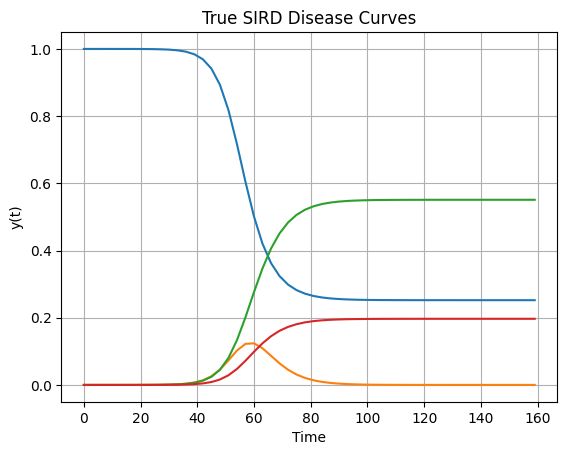

In [159]:
plt.plot(t_train, y_train)
plt.xlabel("Time")
plt.ylabel("y(t)")
plt.title("True SIRD Disease Curves")
plt.grid()
plt.show()

## Build a custom neural network for SIRD model

In [134]:
# This custom neural network model is designed to accept one input (time) and produce 4 outputs (s, i, r, d)

class MLP(nn.Module):
    def __init__(self, hidden =32, depth= 3):
        super().__init__()
        layers = [nn.Linear(1,hidden), nn.Tanh()]
        for i in range(depth-1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers += [nn.Linear(hidden, 4)]
        self.net = nn.Sequential(*layers)

    def forward(self, tau):
        return self.net(tau)

model = MLP()

## Make unknown rates trainable

We start with a wrong parameter values and train them accordingly 

In [137]:
Guess = {"beta": 0.80, "gamma":0.10, "omega":0.15}

# Train the parameters
log_beta = nn.Parameter(torch.log(torch.tensor(Guess["beta"])))
log_gamma = nn.Parameter(torch.log(torch.tensor(Guess["gamma"])))
log_omega = nn.Parameter(torch.log(torch.tensor(Guess["omega"])))

def rates():
    return torch.exp(log_beta), torch.exp(log_gamma), torch.exp(log_omega)

## Build a customized loss function

In [155]:
# We start with the data loss
tau_train = torch.tensor(t_train/T_max, dtype = torch.float32).reshape(-1,1)
y_obs = torch.tensor(y_train, dtype=torch.float32)
mse = nn.MSELoss()
# loss_data = mse(model(tau_train), y_obs)

# Initial condition loss
tau0 = torch.zeros(1,1)
y0 = torch.tensor([Y0], dtype=torch.float32)
# loss_ic = mse(model(tau0), y0)

# Physics informed loss

tau_coll = torch.tensor(t_dense/T_max, dtype = torch.float32).reshape(-1,1)
tau_coll.requires_grad_(True)  # we will diff wrt to this input

def d_dtau(output, tau):  # d(output)d(input)
    return torch.autograd.grad(output, tau,
                               grad_outputs = torch.ones_like(output),
                               create_graph=True)[0]

def physics_residual():
    u = model(tau_coll)
    s,i,r,d = u[:, 0:1], u[:,1:2], u[:,2:3], u[:,3:4]
    beta, gamma, omega = rates()
    ds, di = d_dtau(s, tau_coll), d_dtau(i, tau_coll)
    dr, dd = d_dtau(r, tau_coll), d_dtau(d, tau_coll)
    
    rS = ds - T_max*(-beta*s*i)
    rI = di - T_max*(beta*s*i - gamma*i - omega*i)
    rR = dr - T_max*(gamma*i)
    rD = dd - T_max*(omega*i)
    return torch.cat([rS, rI, rR, rD], dim=1)
    



## Build Neural Network Training Loop

We define the weights

In [165]:
W_data, W_phy, W_ic = 1.0, 1e-4, 1.0
params = list(model.parameters()) + [log_beta, log_gamma, log_omega]
opt = torch.optim.Adam(params, lr= 1e-3)
iters = 20000

In [178]:
for iter in range(iters+1):
    opt.zero_grad()  # clears last step's gradient
    loss_data = mse(model(tau_train), y_obs)
    loss_ic = mse(model(tau0,), y0)
    loss_phys = (physics_residual()**2).mean()
    loss = W_data*loss_data + W_phy*loss_phys + W_ic*loss_ic
    loss.backward()
    opt.step()
    if iter % 2000 ==0:
        b, g, o = (float(x) for x in rates())
        print(f"iter {iter: 6d} | loss: {float(loss):.3e} | "
             f"beta: {b: .4f} | gamma: {g: .4f} | omega: {o: .4f}")

iter      0 | loss: 6.015e-01 | beta:  0.7992 | gamma:  0.0999 | omega:  0.1499
iter   2000 | loss: 5.388e-05 | beta:  0.4649 | gamma:  0.1900 | omega:  0.0733
iter   4000 | loss: 3.359e-06 | beta:  0.4946 | gamma:  0.1985 | omega:  0.0713
iter   6000 | loss: 1.053e-06 | beta:  0.4983 | gamma:  0.1991 | omega:  0.0718
iter   8000 | loss: 5.548e-07 | beta:  0.4998 | gamma:  0.1997 | omega:  0.0717
iter  10000 | loss: 3.664e-07 | beta:  0.5000 | gamma:  0.1999 | omega:  0.0717
iter  12000 | loss: 2.547e-07 | beta:  0.5001 | gamma:  0.2000 | omega:  0.0716
iter  14000 | loss: 1.847e-06 | beta:  0.4996 | gamma:  0.1999 | omega:  0.0715
iter  16000 | loss: 1.026e-05 | beta:  0.4993 | gamma:  0.1999 | omega:  0.0715
iter  18000 | loss: 1.530e-07 | beta:  0.5002 | gamma:  0.2000 | omega:  0.0715
iter  20000 | loss: 1.890e-06 | beta:  0.5000 | gamma:  0.2000 | omega:  0.0715


In [238]:
# We show recovered rates
b, g , o = (float(x) for x in rates() )
pred = {"beta": b, "gamma": g, "omega": o}
print(f"{'param':>6} | {'true': >8} | {'guess': >8} | {'recovered': >10} | {'rel. error':>8}")
for k in pred:
    rel = abs(pred[k]- TRUE[k])/ abs(TRUE[k])
    print(f"{k:>6} | {TRUE[k]:8.4f} | {Guess[k]:8.4f} | {pred[k]:10.4f} | {rel:8.4f}")

 param |     true |    guess |  recovered | rel. error
  beta |   0.5000 |   0.8000 |     0.5000 |   0.0000
 gamma |   0.2000 |   0.1000 |     0.2000 |   0.0002
 omega |   0.0714 |   0.1500 |     0.0715 |   0.0009


## Trajectory Plot

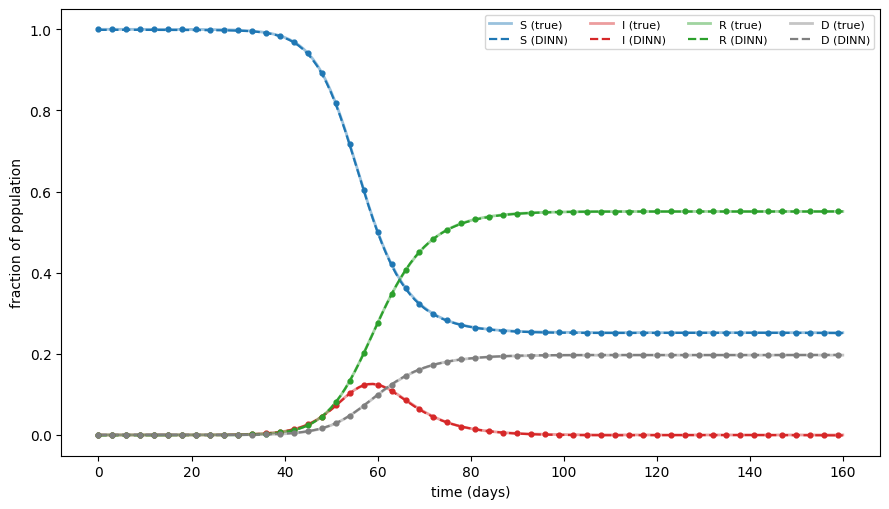

In [242]:
with torch.no_grad():
    tau_plot = torch.tensor(t_dense/T_max, dtype= torch.float32).reshape(-1,1)
    y_pred = model(tau_plot).numpy()

fig, ax = plt.subplots(figsize=(9, 5.2))
labels = ["S", "I", "R", "D"]; colors = ["#1f77b4", "#d62728", "#2ca02c", "#7f7f7f"]
for k in range(4):
    ax.plot(t_dense, y_dense_true[:, k], color=colors[k], lw=2, alpha=0.45,
    label=f"{labels[k]} (true)")
    ax.plot(t_dense, y_pred[:, k], color=colors[k], lw=1.6, ls="--",
    label=f"{labels[k]} (DINN)")
    ax.scatter(t_train, y_train[:, k], color=colors[k], s=12, zorder=3)
    
ax.set_xlabel("time (days)"); ax.set_ylabel("fraction of population")

ax.legend(ncol=4, fontsize=8); fig.tight_layout(); fig.savefig("pinndemic_fit.png",dpi=140)